In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt

import jutuldarcy as jd
from juliacall import Main as jl

from deepfield import Field

C:\Users\mushe\anaconda3\envs\deepfield_app\Lib\site-packages\jutuldarcy\julia_import.py:9: UserWarning: juliacall module already imported. Make sure that you have set the environment variable `PYTHON_JULIACALL_HANDLE_SIGNALS=yes` to avoid segfaults. Also note that jutuldarcy will not be able to configure `PYTHON_JULIACALL_THREADS` or `PYTHON_JULIACALL_OPTLEVEL` for you.
  warnings.warn(


In [3]:
path = './open_data/egg/Egg_Model_ECL.DATA'

In [4]:
case = jd.setup_case_from_data_file(path)

In [5]:
state0_pressure = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Pressure]")(case.state0)
).reshape(1, -1)

state0_sats = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Saturations]")(case.state0)
).reshape(1, 2, -1)

In [46]:
model = Field(path).load()

INFO:Field:Using default config.
INFO:Field:Start reading Egg_Model_ECL.DATA
INFO:Field:Reading section RUNSPEC
INFO:Field:[Egg_Model_ECL.DATA:9] Loading TITLE
INFO:Field:[Egg_Model_ECL.DATA:16] Loading DIMENS
INFO:Field:[Egg_Model_ECL.DATA:19] Loading METRIC
INFO:Field:[Egg_Model_ECL.DATA:20] Loading OIL
INFO:Field:[Egg_Model_ECL.DATA:21] Loading WATER
INFO:Field:[Egg_Model_ECL.DATA:41] Loading START
INFO:Field:Reading section GRID
INFO:Field:[Egg_Model_ECL.DATA:55] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\ACTIVE.INC
INFO:Field:Start reading ACTIVE.INC
INFO:Field:[ACTIVE.INC:1] Loading ACTNUM
INFO:Field:Finish reading ACTIVE.INC
INFO:Field:[Egg_Model_ECL.DATA:58] Loading DX
INFO:Field:[Egg_Model_ECL.DATA:62] Loading DY
INFO:Field:[Egg_Model_ECL.DATA:66] Loading DZ
INFO:Field:[Egg_Model_ECL.DATA:69] Loading TOPS
INFO:Field:[Egg_Model_ECL.DATA:73] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\mDARCY.INC
INFO:Field:Start reading mDARCY.INC

In [7]:
res = jd.simulate_data_file(path, convert = True)

Jutul: Simulating 9 years, 44.69 weeks as 120 report steps


Progress   2%|█                                          |  ETA: 0:22:25
   Progress: Solving step 2/120 (1.67% of time interval complete)
   Stats: 34 iterations in 21.12 s (621.06 ms each)

Progress   2%|██                                         |  ETA: 0:16:10
   Progress: Solving step 3/120 (2.50% of time interval complete)
   Stats: 49 iterations in 22.51 s (459.35 ms each)

Progress   3%|██                                         |  ETA: 0:12:30
   Progress: Solving step 4/120 (3.33% of time interval complete)
   Stats: 59 iterations in 23.47 s (397.80 ms each)

Progress   4%|██                                         |  ETA: 0:10:17
   Progress: Solving step 5/120 (4.17% of time interval complete)
   Stats: 69 iterations in 24.41 s (353.79 ms each)

Progress   5%|███                                        |  ETA: 0:08:51
   Progress: Solving step 6/120 (5.00% of time interval complete)
   Stats: 80 iterations in 25.53 s (319.07 ms each)

Progress   6%|███                       

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 120 steps │ 154 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   4.35833 │        3.3961 │  523 (0) │
│ Linearization  │   5.64167 │        4.3961 │  677 (0) │
│ Linear solver  │   20.8417 │       16.2403 │ 2501 (0) │
│ Precond apply  │   41.6833 │       32.4805 │ 5002 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬─────────╮
│ Timing type   │     Each │   Relative │   Total │
│               │       ms │ Percentage │       s │
├───────────────┼──────────┼────────────┼─────────┤
│ Properties    │   4.0559 │     2.73 % │  2.1212 │
│ Equations     │  10.6767 │     9.29 % │  7.2281 │
│ Assembly      │   7.7728 │     6.76 % │  5.2622 │
│ Linear solve  │  10.3597 │     6.96 % │  5.4181 │
│ Linear setup  │  54.4795 │    36.61 % │ 28.4928 │
│ Precond 

In [8]:
n_steps = len(res['STATES'])
jd_pressure = np.array([res['STATES'][i]['Pressure'] for i in range(n_steps)])
jd_sats = np.array([res['STATES'][i]['Saturations'] for i in range(n_steps)])

In [9]:
df_pressure = np.vstack([state0_pressure, jd_pressure])
df_sats = np.vstack([state0_sats, jd_sats])

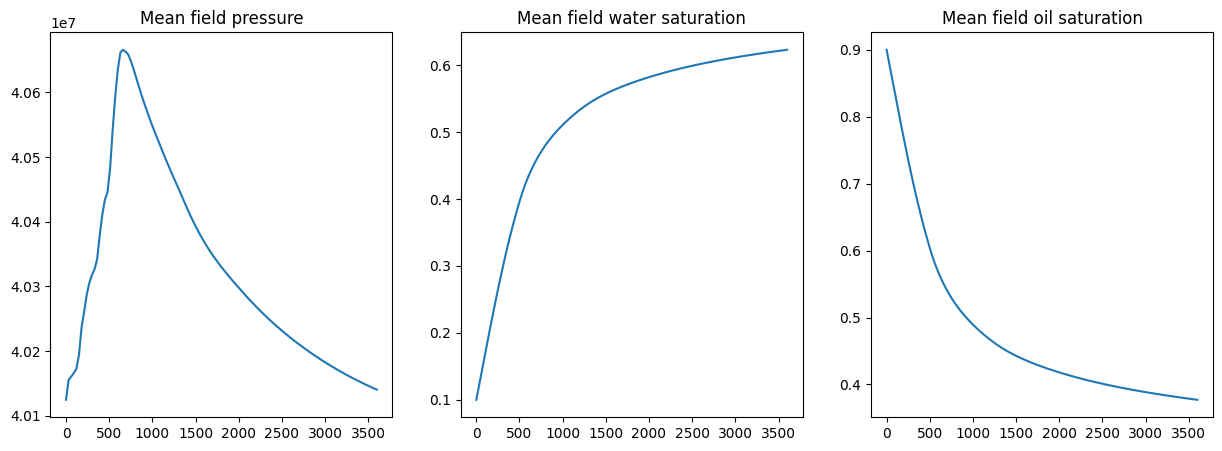

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

days = np.hstack([0., res["DAYS"]])
pressure = df_pressure.mean(axis=1)
swat = df_sats[:, 0, :].mean(axis=1)
soil = df_sats[:, 1, :].mean(axis=1)

ax[0].set_title("Mean field pressure")
ax[0].plot(days, pressure)
ax[1].set_title("Mean field water saturation")
ax[1].plot(days, swat)
ax[2].set_title("Mean field oil saturation")
ax[2].plot(days, soil)

In [11]:
model.states.attributes

()

In [47]:
model.states.pressure = df_pressure

In [48]:
model.states.soil = df_sats[:, 1, :]

In [49]:
model.states.swat = df_sats[:, 0, :]

In [50]:
model.states.to_spatial()

In [51]:
model.show(attr="SWAT")

In [52]:
n_timestamps = len(res["DAYS"])

In [53]:
start_date = case.input_data["RUNSPEC"]["START"]
timestamps = [start_date + timedelta(days=res["DAYS"][i]) for i in range(n_timestamps)]
dates = pd.DataFrame({"DATE": timestamps})

In [54]:
welldata = {}

In [63]:
dates

,DATE
0,2011-07-15
1,2011-08-14
2,2011-09-13
3,2011-10-13
4,2011-11-12
...,...
115,2020-12-24
116,2021-01-23
117,2021-02-22
118,2021-03-24


In [64]:
def results(well_df):
    results_df = pd.concat([dates, pd.DataFrame(well_df)], axis=1)
    record0 = pd.DataFrame([[start_date] + [0.0]*(len(well_df.columns))], columns = results_df.columns)
    results_df = pd.concat([record0, results_df])
    return results_df

In [65]:
wellnames = res["WELLS"].keys()
welldata = {w: {"RESULTS": results(pd.DataFrame(res["WELLS"][w]))} for w in wellnames}

In [66]:
model.wells.update(welldata)

In [67]:
model.wells.show_rates()

interactive(children=(Dropdown(description='wellname', options=('FIELD', '1', 'INJECT1', 'INJECT2', 'INJECT3',…